## Drumhead modes

Intuitively, I would think that a drumhead would be defined by a circular wave equation, and so the modes would be defined based off of the inverse of the radius. The wave function in plar coordinates is defined as:

$$\nabla^2 u = \frac{\partial^2 u}{\partial r^2} + \frac{1}{r}\frac{\partial u}{\partial r} + \frac{1}{r^2}\frac{\partial^2 u}{\partial \theta^2}$$

We can use the separate of variables method and set:

$$u(r, \theta, t) = R(r)\,\Theta(\theta)\,\mathcal{T}(t)$$


Substitute $u = R(r)\,\Theta(\theta)\,\mathcal{T}(t)$ into the wave equation:

$$R\,\Theta\,\mathcal{T}'' = c^2\left(R''\Theta\mathcal{T} + \frac{1}{r}R'\Theta\mathcal{T} + \frac{1}{r^2}R\,\Theta''\mathcal{T}\right)$$

Divide everything by $R\,\Theta\,\mathcal{T}$:

$$\frac{\mathcal{T}''}{\mathcal{T}} = c^2\left(\frac{R''}{R} + \frac{1}{r}\frac{R'}{R} + \frac{1}{r^2}\frac{\Theta''}{\Theta}\right)$$




Therefore, we get that:
$$\mathcal{T}''(t) + \omega^2\,\mathcal{T}(t) = 0$$

and that becomes $\mathcal{T}(t) = e^{\pm i\omega t}$

on the other side of the equation, we have the spatial component changing:
$$c^2\left(\frac{R''}{R} + \frac{1}{r}\frac{R'}{R} + \frac{1}{r^2}\frac{\Theta''}{\Theta}\right) = -\omega^2$$


We can then rearrange to be able to separate out $\theta$ from $\r$:
$$r^2\frac{R''}{R} + r\frac{R'}{R} + \frac{\omega^2 r^2}{c^2} = -\frac{\Theta''}{\Theta}$$

which means that we now have the LHS depend on ly on r and the RHS depend only on \theta.

$${\Theta''(\theta) + m^2\,\Theta(\theta) = 0}$$

We can therefore use the constant $m^2$ (we are using that so we can nicely slot into the bessel equation):
$\Theta(\theta) = e^{\pm im\theta}$, or $C\cos(m\theta) + D\sin(m\theta)$.

This allows us to use the general form of the bessl equation:
$$r^2 R'' + r R' + (k^2 r^2 - m^2)R = 0$$

Bessel's equation is a second-order ODE, so it has two linearly independent solutions**:

1. $J_m(kr)$ which is finite at $r = 0$
2. $Y_m(kr)$ which diverges as $r \to 0$

The centre of the drum ($r = 0$) is a physical point — the displacement must be finite there. Since $Y_m(kr) \to -\infty$ as $r \to 0$, we must discard it.

$${R(r) = J_m(kr)}$$

To find the **six lowest** modes, we collect all the zeros $j_{mn}$ (for various $m$ and $n$) and sort them in ascending order — since $f \propto j_{mn}$, the smallest zeros give the lowest frequencies.

Therefore, when we analytically solve for this, the normal modes are:

$${u_{mn}(r, \theta, t) = J_m\!\left(\frac{j_{mn}\,r}{L}\right)\left[C\cos(m\theta) + D\sin(m\theta)\right]\cos(\omega_{mn} t - \phi)}$$

The spatial pattern is:

$$\Phi_{mn}(r, \theta) = J_m\!\left(\frac{j_{mn}\,r}{L}\right)\cos(m\theta)$$

## Trying to plot the drum modes

<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:37: SyntaxWarning: invalid escape sequence '\l'
/var/folders/37/mbm5qm1d03lg63qfy97k4tmw0000gn/T/ipykernel_14599/1261420996.py:37: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title(f"Mode {i+1}\n$\lambda$={-vals[i]:.2f}")


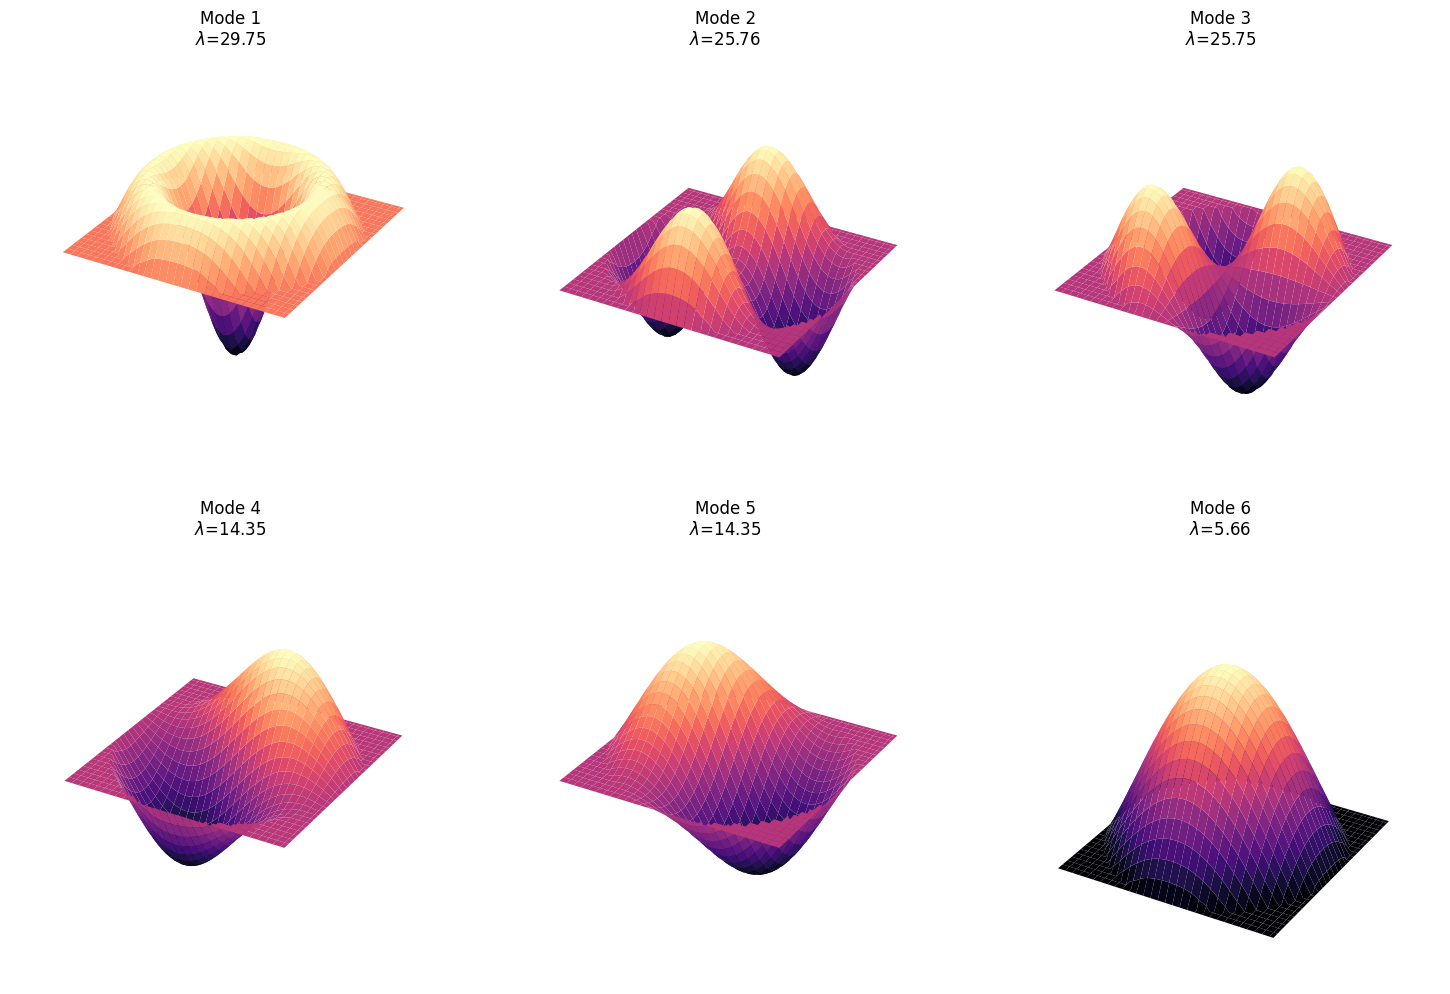

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import dok_matrix
from scipy.sparse.linalg import eigsh

def solve_drum_modes(N=60):
    L = 1.0
    x = np.linspace(-L, L, N)
    y = np.linspace(-L, L, N)
    X, Y = np.meshgrid(x, y)
    dist_sq = X**2 + Y**2
    inside_mask = dist_sq <= L**2
    indices = np.where(inside_mask.ravel())[0]
    id_map = {idx: i for i, idx in enumerate(indices)} 
    num_pts = len(indices)
    h = x[1] - x[0]
    A = dok_matrix((num_pts, num_pts))
    for i in range(N):
        for j in range(N):
            flat_idx = i * N + j
            if inside_mask[i, j]:
                row = id_map[flat_idx]
                A[row, row] = -4 / h**2
                for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
                    ni, nj = i + di, j + dj
                    n_flat = ni * N + nj
                    if 0 <= ni < N and 0 <= nj < N and inside_mask[ni, nj]:
                        col = id_map[n_flat]
                        A[row, col] = 1 / h**2             
    vals, vecs = eigsh(A, k=6, which='SM')
    fig = plt.figure(figsize=(15, 10))
    for i in range(6):
        mode_grid = np.zeros((N, N))
        mode_grid[inside_mask] = vecs[:, i]
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        ax.plot_surface(X, Y, mode_grid, cmap='magma', edgecolor='none')
        ax.set_title(f"Mode {i+1}\n$\lambda$={-vals[i]:.2f}")
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

solve_drum_modes()

### Asking an LLM what the best way to plot this problem is - my above solution and sparse grid was too course and shows the wrong modes!

(and of course, scipy saves the day )

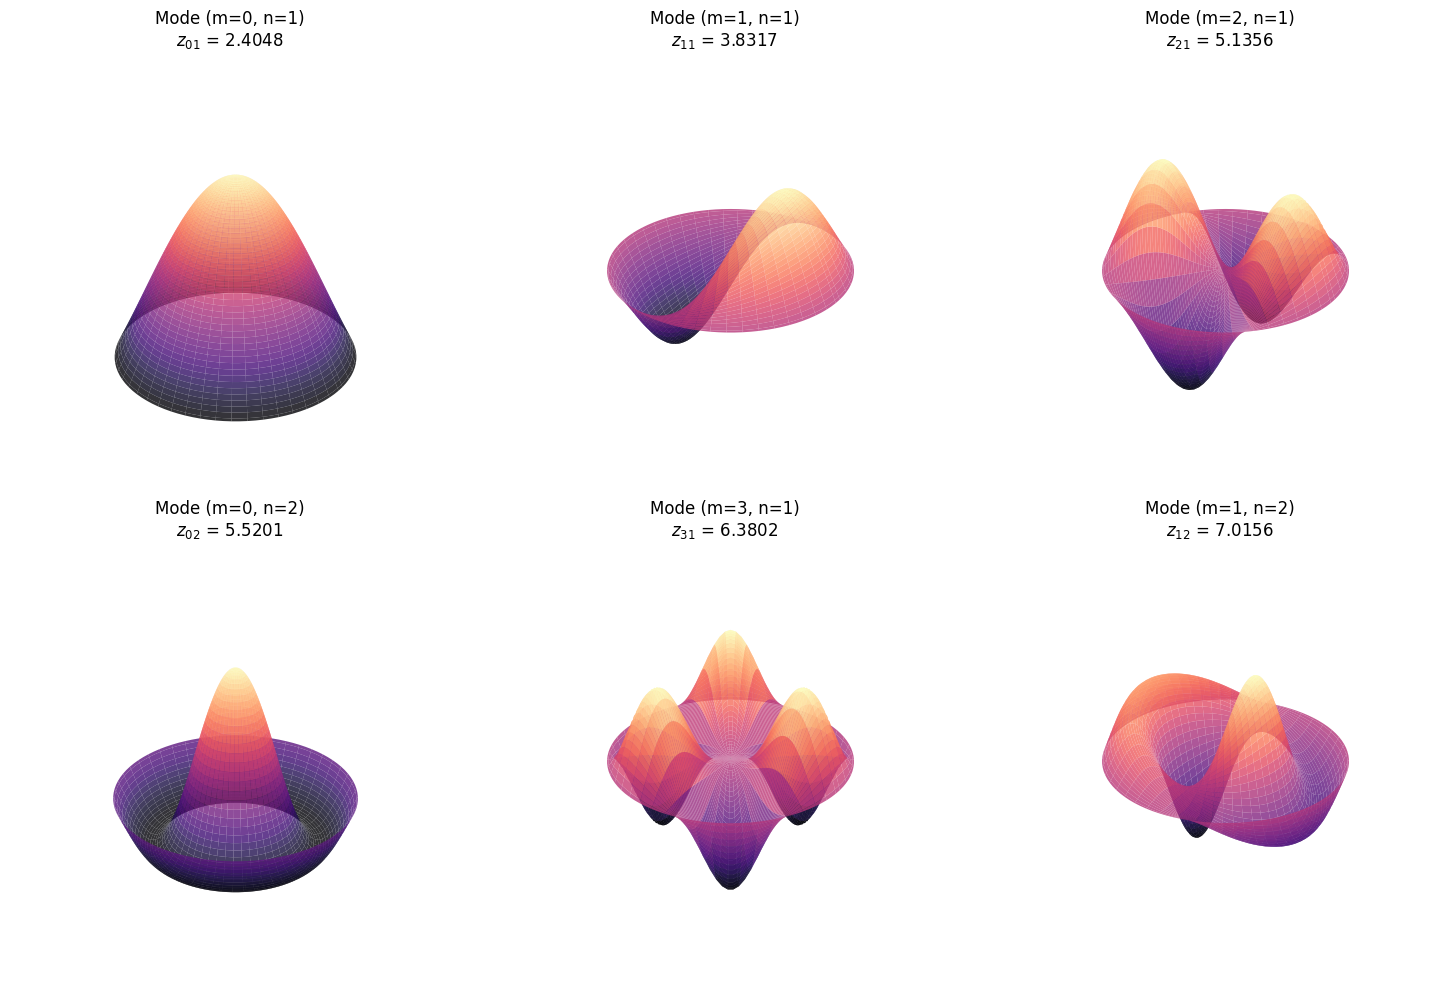

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn, jn_zeros

def plot_drums():
    r = np.linspace(0, 1, 100)
    theta = np.linspace(0, 2*np.pi, 100)
    R, Theta = np.meshgrid(r, theta)
    X, Y = R*np.cos(Theta), R*np.sin(Theta)
    modes = [(0, 1), (1, 1), (2, 1), (0, 2), (3, 1), (1, 2)]
    fig = plt.figure(figsize=(15, 10))
    for i, (m, n) in enumerate(modes):
        z_mn = jn_zeros(m, n)[n-1]
        Z = jn(m, z_mn * R) * np.cos(m * Theta)
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='none', alpha=0.8)
        ax.set_title(f"Mode (m={m}, n={n})\n$z_{{{m}{n}}}$ = {z_mn:.4f}")
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

plot_drums()